In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gudhi as gd

In [2]:
ruta = "https://raw.githubusercontent.com/HaydeePeruyero/tda-cell-patterns-workshop/main/data/carcinoma_FA_HN14_2.csv"

df = pd.read_csv(ruta)

x = df["X_centroid"].to_numpy()
y = df["Y_centroid"].to_numpy()

puntos = np.column_stack((x, y))

print(f"Número de puntos: {len(puntos)}")

Número de puntos: 1030


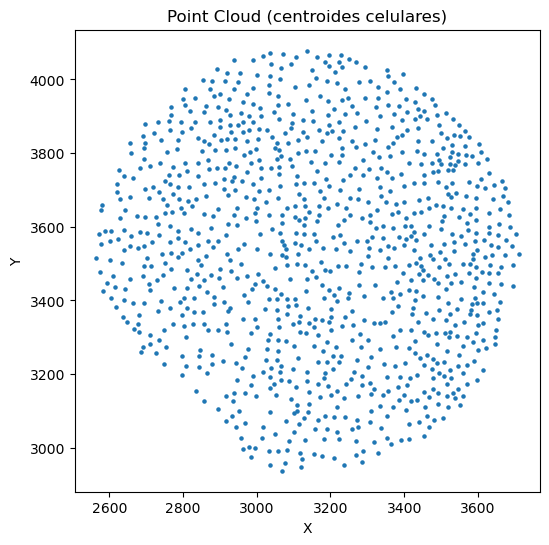

In [3]:
plt.figure(figsize=(6,6))
plt.scatter(x, y, s=5)

plt.title("Point Cloud (centroides celulares)")
plt.xlabel("X")
plt.ylabel("Y")

plt.show()

In [4]:
radio = 50

rips_complex = gd.RipsComplex(
    points=puntos,
    max_edge_length=radio
)

simplex_tree = rips_complex.create_simplex_tree(
    max_dimension=2
)

print("Número de simplices:", simplex_tree.num_simplices())

Número de simplices: 9121


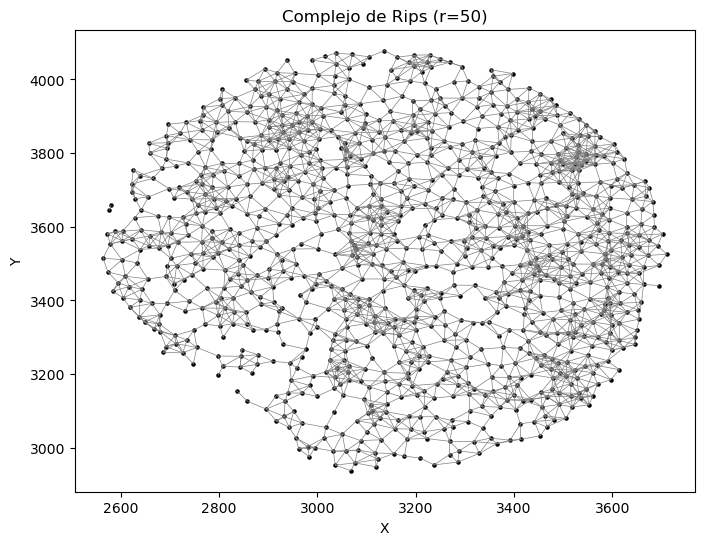

In [5]:
plt.figure(figsize=(8,6))
plt.scatter(x, y, color="black", s=5)

for simplex in simplex_tree.get_skeleton(1):
    if len(simplex[0]) == 2:
        i, j = simplex[0]

        plt.plot(
            [x[i], x[j]],
            [y[i], y[j]],
            color="gray",
            linewidth=0.5
        )

plt.title(f"Complejo de Rips (r={radio})")
plt.xlabel("X")
plt.ylabel("Y")

plt.show()

In [6]:
diag = simplex_tree.persistence()

print("Primeros valores:")
print(diag[:10])

Primeros valores:
[(1, (36.50843414019692, inf)), (1, (34.89826559940533, inf)), (1, (34.94464363154827, inf)), (1, (35.07773869438781, inf)), (1, (35.08834896071297, inf)), (1, (35.147632669852634, inf)), (1, (35.21930408753491, inf)), (1, (35.3060076839965, inf)), (1, (35.31815355881978, inf)), (1, (35.488743972397636, inf))]


usetex mode requires TeX.


<Figure size 600x600 with 0 Axes>

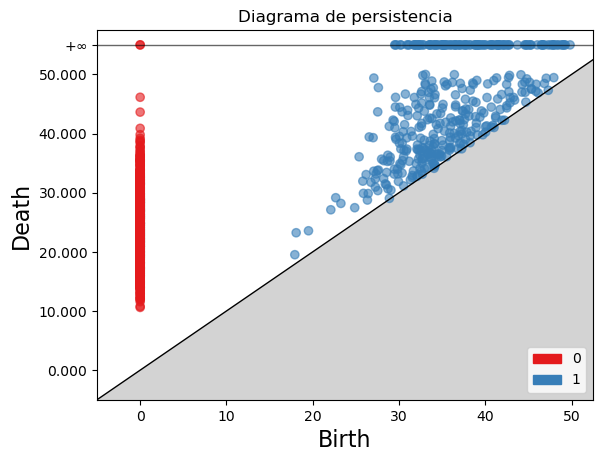

In [7]:
plt.figure(figsize=(6,6))
gd.plot_persistence_diagram(diag)
plt.title("Diagrama de persistencia")
plt.show()

In [8]:
output = pd.DataFrame(
    [[dim, b, d] for dim, (b, d) in diag if dim <= 2],
    columns=["dimension", "birth", "death"]
)

output.head()

,dimension,birth,death
0,1,36.508434,inf
1,1,34.898266,inf
2,1,34.944644,inf
3,1,35.077739,inf
4,1,35.088349,inf


In [9]:
output

,dimension,birth,death
0,1,36.508434,inf
1,1,34.898266,inf
2,1,34.944644,inf
3,1,35.077739,inf
4,1,35.088349,inf
...,...,...,...
1418,0,0.000000,12.049791
1419,0,0.000000,11.872265
1420,0,0.000000,11.576476
1421,0,0.000000,10.783573


In [13]:
import os
import requests
import numpy as np
import pandas as pd
import gudhi as gd

# ============================================================
# 1. OBTENER LISTA DE ARCHIVOS DESDE GITHUB
# ============================================================

api_url = (
    "https://api.github.com/repos/"
    "HaydeePeruyero/tda-cell-patterns-workshop/contents/data"
)

contenido = requests.get(api_url).json()

archivos = sorted([
    f["name"]
    for f in contenido
    if f["name"].endswith(".csv")
])

print("Archivos encontrados:")
for archivo in archivos:
    print("-", archivo)

# ============================================================
# 2. RUTA RAW DE GITHUB
# ============================================================

ruta = (
    "https://raw.githubusercontent.com/"
    "HaydeePeruyero/tda-cell-patterns-workshop/main/data/"
)

# ============================================================
# 3. CREAR CARPETA DE SALIDA
# ============================================================

os.makedirs("resultados", exist_ok=True)

# ============================================================
# 4. PROCESAR TODOS LOS ARCHIVOS
# ============================================================

for archivo in archivos:

    print(f"\nProcesando: {archivo}")

    # -------------------------
    # Cargar datos
    # -------------------------

    df = pd.read_csv(ruta + archivo)

    # -------------------------
    # Coordenadas
    # -------------------------

    x = df["X_centroid"].to_numpy()
    y = df["Y_centroid"].to_numpy()

    # -------------------------
    # Nube de puntos
    # -------------------------

    puntos = np.column_stack((x, y))

    print(f"Número de puntos: {len(puntos)}")

    # -------------------------
    # Complejo de Rips
    # -------------------------

    rips_complex = gd.RipsComplex(
        points=puntos,
        max_edge_length=50
    )

    simplex_tree = rips_complex.create_simplex_tree(
        max_dimension=2
    )

    # -------------------------
    # Homología persistente
    # -------------------------

    diag = simplex_tree.persistence()

    # -------------------------
    # Convertir a DataFrame
    # -------------------------

    output = pd.DataFrame(
        [[dim, b, d] for dim, (b, d) in diag if dim <= 2],
        columns=["dimension", "birth", "death"]
    )

    # -------------------------
    # Guardar resultado
    # -------------------------

    nombre_salida = archivo.replace(".csv", "_diag.csv")

    output.to_csv(
        os.path.join("resultados", nombre_salida),
        index=False
    )

    print(f"Guardado: resultados/{nombre_salida}")

Archivos encontrados:
- carcinoma_FA_HN14_2.csv
- dysplasia_FA_HN11A_1.csv
- stroma_ad_carcinoma_FA_HN14_3.csv
- stroma_ad_dysplasia_FA_HN11A_5.csv

Procesando: carcinoma_FA_HN14_2.csv
Número de puntos: 1030
Guardado: resultados/carcinoma_FA_HN14_2_diag.csv

Procesando: dysplasia_FA_HN11A_1.csv
Número de puntos: 1035
Guardado: resultados/dysplasia_FA_HN11A_1_diag.csv

Procesando: stroma_ad_carcinoma_FA_HN14_3.csv
Número de puntos: 1045
Guardado: resultados/stroma_ad_carcinoma_FA_HN14_3_diag.csv

Procesando: stroma_ad_dysplasia_FA_HN11A_5.csv
Número de puntos: 1049
Guardado: resultados/stroma_ad_dysplasia_FA_HN11A_5_diag.csv


In [18]:
import os
import requests
import numpy as np
import pandas as pd
import gudhi as gd

# ============================================================
# 1. OBTENER LISTA DE ARCHIVOS DESDE GITHUB
# ============================================================

api_url = (
    "https://api.github.com/repos/"
    "HaydeePeruyero/tda-cell-patterns-workshop/contents/data"
)

contenido = requests.get(api_url).json()

archivos = sorted([
    f["name"]
    for f in contenido
    if f["name"].endswith(".csv")
])

print("Archivos encontrados:")
for archivo in archivos:
    print("-", archivo)

# ============================================================
# 2. RUTA RAW DE GITHUB
# ============================================================

ruta = (
    "https://raw.githubusercontent.com/"
    "HaydeePeruyero/tda-cell-patterns-workshop/main/data/"
)

# ============================================================
# 3. CREAR CARPETA DE SALIDA
# ============================================================

os.makedirs("resultados", exist_ok=True)

# ============================================================
# 4. PROCESAR TODOS LOS ARCHIVOS
# ============================================================

for archivo in archivos:

    print(f"\nProcesando: {archivo}")

    # -------------------------
    # Cargar datos
    # -------------------------

    df = pd.read_csv(ruta + archivo)

    # -------------------------
    # Coordenadas
    # -------------------------

    x = df["X_centroid"].to_numpy()
    y = df["Y_centroid"].to_numpy()

    # -------------------------
    # Nube de puntos
    # -------------------------

    puntos = np.column_stack((x, y))

    print(f"Número de puntos: {len(puntos)}")

    # -------------------------
    # Complejo de Rips
    # -------------------------

    rips_complex = gd.RipsComplex(
        points=puntos,
        max_edge_length=300
    )

    simplex_tree = rips_complex.create_simplex_tree(
        max_dimension=2
    )

    # -------------------------
    # Homología persistente
    # -------------------------

    diag = simplex_tree.persistence()

    # -------------------------
    # Convertir a DataFrame
    # -------------------------

    output = pd.DataFrame(
        [[dim, b, d] for dim, (b, d) in diag if dim <= 2],
        columns=["dimension", "birth", "death"]
    )

    # -------------------------
    # Guardar resultado
    # -------------------------

    nombre_salida = archivo.replace(".csv", "_diag.csv")

    output.to_csv(
        os.path.join("resultados", nombre_salida),
        index=False
    )

    print(f"Guardado: resultados/{nombre_salida}")

Archivos encontrados:
- Epithelium_HGD_FAAGSCC_13_FAAGSCC_13_HGD_15_derecha-izquierda.csv
- Epithelium_HGD_FAAGSCC_13_FAAGSCC_13_HGD_2_derecha-izquierda.csv
- Epithelium_HGD_FAAGSCC_13_FAAGSCC_13_HGD_7_derecha-izquierda.csv
- Epithelium_IC_AGSCC_1_AGSCC_1_IC_18_izquierda-derecha.csv
- Epithelium_IC_AGSCC_1_AGSCC_1_IC_24_izquierda-derecha.csv
- Epithelium_IC_AGSCC_1_AGSCC_1_IC_28_izquierda-derecha.csv
- Epithelium_LGD_F82P1_F82P1_LGD_5_derecha-izquierda.csv
- Epithelium_LGD_F82P1_F82P1_LGD_6_derecha-izquierda.csv
- Stroma_HGD_FAAGSCC_13_FAAGSCC_13_HGD_4_izquierda-derecha.csv
- Stroma_HGD_FAAGSCC_13_FAAGSCC_13_HGD_7_izquierda-derecha.csv
- Stroma_IC_AGSCC_1_AGSCC_1_IC_111_izquierda-derecha.csv
- Stroma_IC_AGSCC_1_AGSCC_1_IC_99_izquierda-derecha.csv
- Stroma_LGD_F33P1_F33P1_LGD_7_izquierda-derecha.csv
- Stroma_LGD_F81P1_F81P1_LGD_1_izquierda-derecha.csv

Procesando: Epithelium_HGD_FAAGSCC_13_FAAGSCC_13_HGD_15_derecha-izquierda.csv
Número de puntos: 2005
Guardado: resultados/Epithelium_HGD